# Task 1: Exploratory Analysis of the SPiFF Series

This notebook addresses Task 1 by answering:
1. What patterns exist within the individual series?
2. What relationships exist between different series?
3. Can the series be grouped? If so, what groups appear?

The analysis follows the project workflow in the README and produces report-ready tables/figures in Output/task1/.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.signal import periodogram
from scipy.spatial.distance import squareform
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

from config.plot_config import plot_config
from Subtasks.series_analysis import PriceAnalysis

output = plot_config() / "task1"
output.mkdir(exist_ok=True)

analysis_raw = PriceAnalysis.from_csv("spiff_data-2.csv")
analysis = analysis_raw.clean()

raw_prices = analysis_raw.prices
cleaned_prices = analysis.prices
log_returns = analysis.log_returns
abs_log_returns = analysis.absolute_log_returns
sq_log_returns = analysis.squared_log_returns

## 1) Data quality and preprocessing checks

We first inspect the raw data, confirm the placeholder corruption pattern, and verify the cleaned dataset used in Task 1.

Raw data preview:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026



Overview of cleaned prices (missingness by series):


,dtype,missing_values,missing_share
gurkor,float64,255,0.046738
guitars,float64,255,0.046738
slingshots,float64,255,0.046738
stocks,float64,255,0.046738
sugar,float64,255,0.046738
water,float64,255,0.046738
tranquillity,float64,255,0.046738



Detected missing-data blocks:


,series,start,end,length,gap_type
0,guitars,399,448,50,internal
1,guitars,5257,5456,200,trailing
2,gurkor,199,248,50,internal
3,gurkor,5257,5456,200,trailing
4,slingshots,599,648,50,internal
5,slingshots,5257,5456,200,trailing
6,stocks,799,848,50,internal
7,stocks,5257,5456,200,trailing
8,sugar,999,1048,50,internal
9,sugar,5257,5456,200,trailing


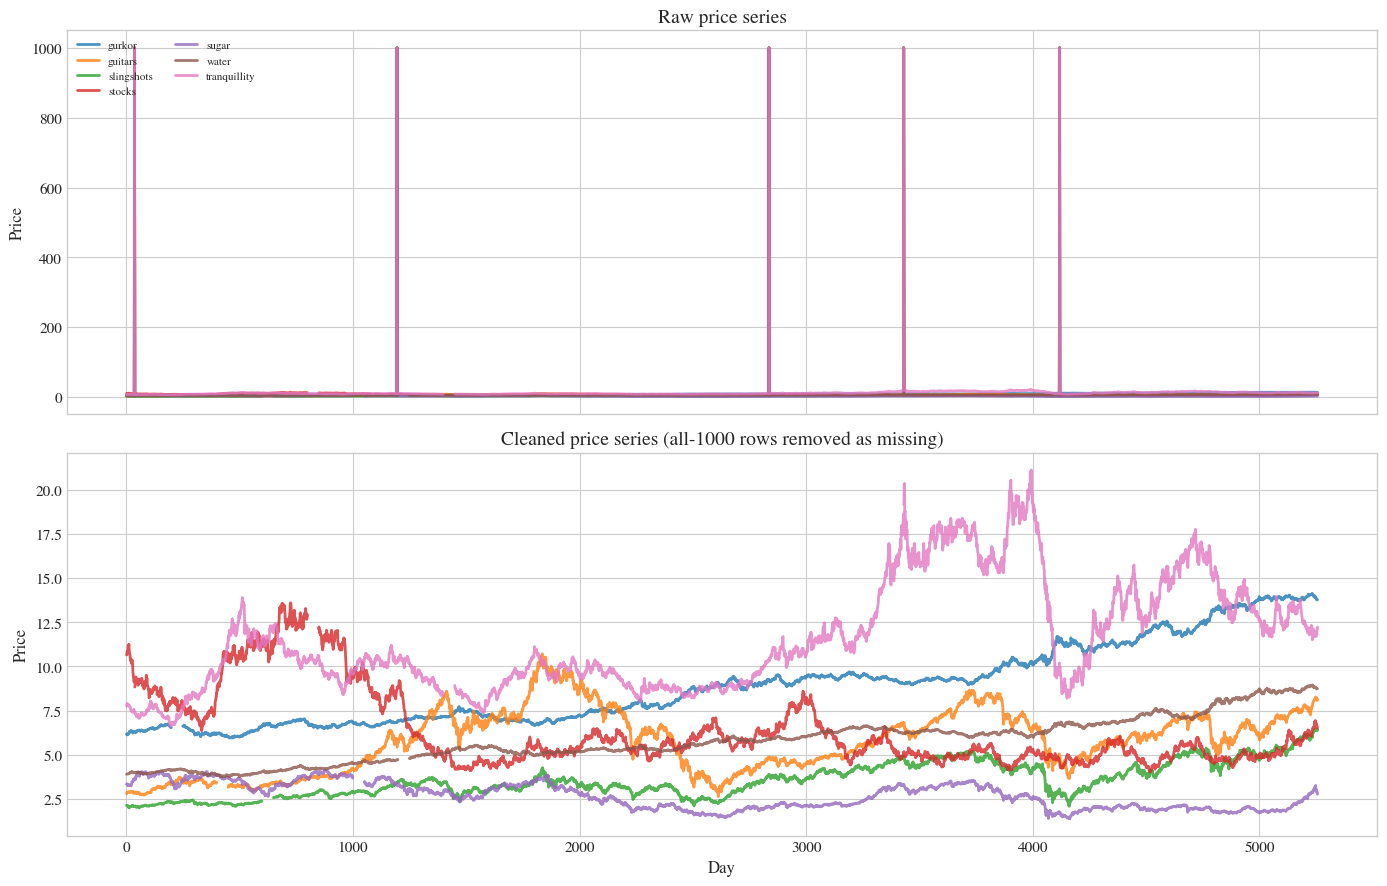

In [25]:
print("Raw data preview:")
display(raw_prices.head())

print("\nOverview of cleaned prices (missingness by series):")
display(analysis.overview())

gap_table = analysis.gap_table()
print("\nDetected missing-data blocks:")
display(gap_table)

gap_table.to_latex(output / "GapTable.tex", index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for col in raw_prices.columns:
    axes[0].plot(raw_prices.index, raw_prices[col], alpha=0.8, label=col)
axes[0].set_title("Raw price series")
axes[0].set_ylabel("Price")

for col in cleaned_prices.columns:
    axes[1].plot(cleaned_prices.index, cleaned_prices[col], alpha=0.8, label=col)
axes[1].set_title("Cleaned price series (all-1000 rows removed as missing)")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Price")

axes[0].legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(output / "raw_vs_cleaned_prices.png")
plt.show()

## 2) What patterns exist within individual series?

We summarize trend, dependence, volatility, and seasonality characteristics per series.
This section now includes Ljung-Box tests plus ACF/PACF diagnostics directly with the pattern analysis.

,raw_price_significant_lags_up_to_30,log_return_significant_lags_up_to_30,abs_log_return_significant_lags_up_to_30,sq_log_return_significant_lags_up_to_30,lb_log_returns_pvalue_lag_10,lb_abs_returns_pvalue_lag_10,lb_sq_returns_pvalue_lag_10,return_mean,return_variance,avg_30d_return_variance,log_price_trend_slope
sugar,30,5,30,30,0.0003,0.0000,0.0000,-0.0000,0.0002,0.0002,-0.0001
stocks,30,1,3,1,0.9345,0.6247,0.7105,-0.0001,0.0002,0.0002,-0.0001
guitars,30,8,30,30,0.0058,0.0000,0.0000,0.0002,0.0002,0.0002,0.0001
slingshots,30,8,30,30,0.0000,0.0000,0.0000,0.0002,0.0002,0.0002,0.0001
tranquillity,30,1,30,30,0.2916,0.0000,0.0000,0.0001,0.0002,0.0002,0.0001
gurkor,30,5,30,29,0.0069,0.0000,0.0000,0.0002,0.0000,0.0000,0.0002
water,30,2,30,30,0.1159,0.0000,0.0000,0.0002,0.0000,0.0000,0.0001


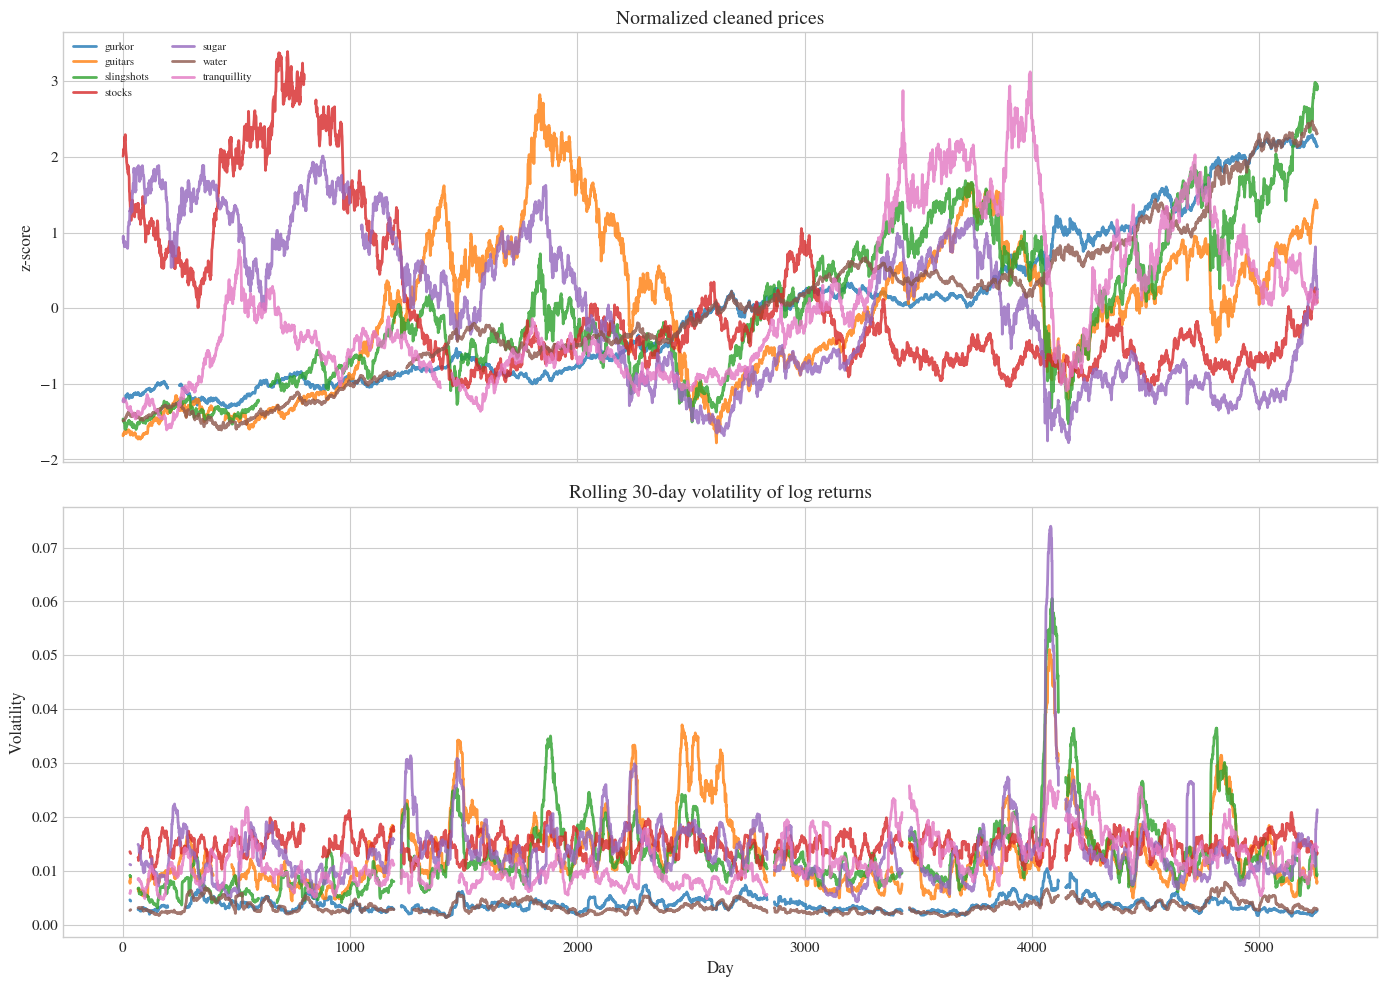

,lb_return_p_lag_10,lb_abs_return_p_lag_10,lb_return_p_lag_20,lb_abs_return_p_lag_20,lb_return_p_lag_30,lb_abs_return_p_lag_30
series,,,,,,
guitars,0.0058,0.0000,0.0002,0.0000,0.0000,0.0000
gurkor,0.0069,0.0000,0.0029,0.0000,0.0057,0.0000
slingshots,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
stocks,0.9345,0.6247,0.8987,0.3759,0.9534,0.1655
sugar,0.0003,0.0000,0.0020,0.0000,0.0003,0.0000
tranquillity,0.2916,0.0000,0.0549,0.0000,0.0531,0.0000
water,0.1159,0.0000,0.3363,0.0000,0.3418,0.0000


,dominant_period_days,peak_strength_vs_median,seasonality_flag
series,,,
guitars,236.409,2213.114,True
gurkor,325.062,2891.154,True
slingshots,305.941,2617.870,True
stocks,346.733,3114.439,True
sugar,325.062,2425.711,True
tranquillity,325.062,5402.639,True
water,325.062,5321.525,True


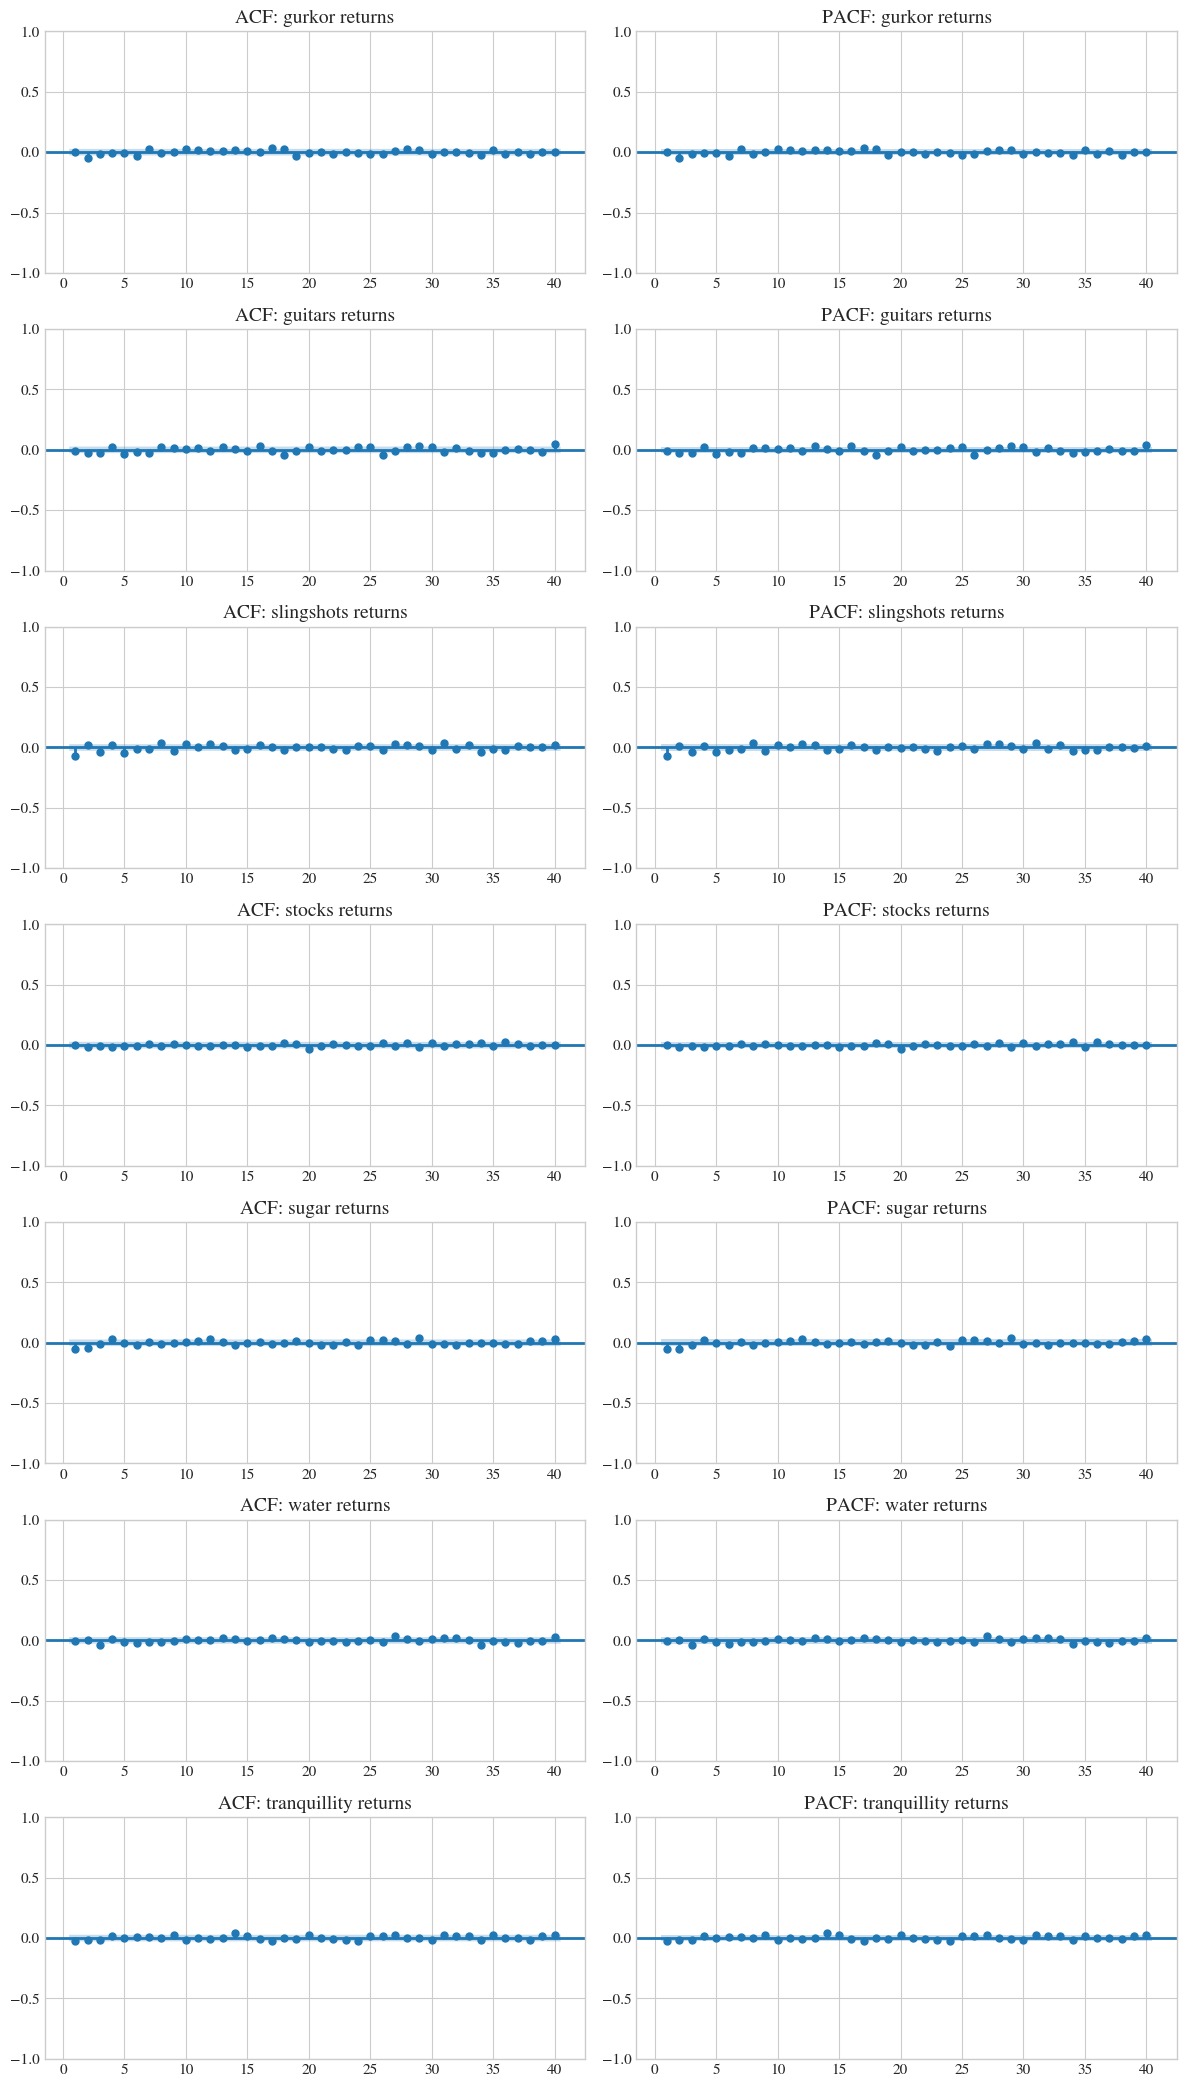


Series-wise interpretation:
- sugar: near-zero mean return, strong serial dependence in prices, clear volatility clustering.
- stocks: near-zero mean return, strong serial dependence in prices, limited volatility clustering.
- guitars: near-zero mean return, strong serial dependence in prices, clear volatility clustering.
- slingshots: near-zero mean return, strong serial dependence in prices, clear volatility clustering.
- tranquillity: near-zero mean return, strong serial dependence in prices, clear volatility clustering.
- gurkor: near-zero mean return, strong serial dependence in prices, clear volatility clustering.
- water: near-zero mean return, strong serial dependence in prices, clear volatility clustering.

Diagnostics guide:
- Ljung-Box p-values < 0.05 suggest significant serial dependence.
- Very low p-values for absolute returns indicate volatility clustering.
- seasonality_flag=True indicates a strong candidate cycle in the 5-400 day range.


In [33]:
comparison = analysis.series_comparison(window=30, max_lag=30)

# Log-price trend slope per series (positive means upward drift in level).
trend_slopes = {}
for col in cleaned_prices.columns:
    s = np.log(cleaned_prices[col].dropna())
    x = np.arange(len(s))
    trend_slopes[col] = np.polyfit(x, s.values, 1)[0]

individual_patterns = comparison[[
    "raw_price_significant_lags_up_to_30",
    "log_return_significant_lags_up_to_30",
    "abs_log_return_significant_lags_up_to_30",
    "sq_log_return_significant_lags_up_to_30",
    "lb_log_returns_pvalue_lag_10",
    "lb_abs_returns_pvalue_lag_10",
    "lb_sq_returns_pvalue_lag_10",
    "return_mean",
    "return_variance",
    "avg_30d_return_variance",
]].copy()
individual_patterns["log_price_trend_slope"] = pd.Series(trend_slopes)
individual_patterns = individual_patterns.sort_values("return_variance", ascending=False)

display(individual_patterns.round(4))
individual_patterns.round(4).to_latex(output / "IndividualPatternsTable.tex")

# Normalized levels and rolling volatility for visual pattern comparison.
norm_prices = (cleaned_prices - cleaned_prices.mean()) / cleaned_prices.std()
rolling_vol = log_returns.rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for col in norm_prices.columns:
    axes[0].plot(norm_prices.index, norm_prices[col], alpha=0.8, label=col)
axes[0].set_title("Normalized cleaned prices")
axes[0].set_ylabel("z-score")

for col in rolling_vol.columns:
    axes[1].plot(rolling_vol.index, rolling_vol[col], alpha=0.8, label=col)
axes[1].set_title("Rolling 30-day volatility of log returns")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Volatility")
axes[0].legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(output / "individual_series_patterns_task1.png")
plt.show()

# Ljung-Box diagnostics on returns and absolute returns.
ljung_rows = []
test_lags = [10, 20, 30]
for col in log_returns.columns:
    r = log_returns[col].dropna()
    ar = abs_log_returns[col].dropna()
    lb_r = acorr_ljungbox(r, lags=test_lags, return_df=True)
    lb_ar = acorr_ljungbox(ar, lags=test_lags, return_df=True)
    row = {"series": col}
    for lag in test_lags:
        row[f"lb_return_p_lag_{lag}"] = lb_r.loc[lag, "lb_pvalue"]
        row[f"lb_abs_return_p_lag_{lag}"] = lb_ar.loc[lag, "lb_pvalue"]
    ljung_rows.append(row)

ljung_df = pd.DataFrame(ljung_rows).set_index("series").sort_index()
display(ljung_df.round(4))
ljung_df.round(6).to_latex(output / "LjungBoxDiagnostics.tex")

# Seasonality check on detrended log-prices.
seasonality_rows = []
for col in cleaned_prices.columns:
    s = np.log(cleaned_prices[col].dropna())
    t = np.arange(len(s))
    slope, intercept = np.polyfit(t, s.values, 1)
    detrended = s.values - (slope * t + intercept)
    detrended = detrended - detrended.mean()

    freq, power = periodogram(detrended, fs=1.0, scaling="spectrum")
    mask = freq > 0
    freq = freq[mask]
    power = power[mask]
    period = np.where(freq > 0, 1.0 / freq, np.nan)
    practical = (period >= 5) & (period <= 400)

    if practical.sum() > 0:
        idx = np.argmax(power[practical])
        practical_periods = period[practical]
        practical_power = power[practical]
        dom_period = float(practical_periods[idx])
        dom_strength = float(practical_power[idx] / (np.median(practical_power) + 1e-12))
    else:
        dom_period = np.nan
        dom_strength = np.nan

    seasonality_rows.append(
        {
            "series": col,
            "dominant_period_days": dom_period,
            "peak_strength_vs_median": dom_strength,
            "seasonality_flag": bool(pd.notna(dom_strength) and dom_strength > 8),
        }
    )

seasonality_df = pd.DataFrame(seasonality_rows).set_index("series").sort_index()
display(seasonality_df.round(3))
seasonality_df.round(6).to_latex(output / "SeasonalityDiagnostics.tex")

# ACF/PACF plots for log returns.
max_lag = 40
n_series = len(log_returns.columns)
fig, axes = plt.subplots(n_series, 2, figsize=(12, 3.0 * n_series))
if n_series == 1:
    axes = np.array([axes])

for i, col in enumerate(log_returns.columns):
    r = log_returns[col].dropna()
    plot_acf(r, lags=max_lag, ax=axes[i, 0], alpha=0.05, zero=False)
    axes[i, 0].set_title(f"ACF: {col} returns")

    plot_pacf(r, lags=max_lag, ax=axes[i, 1], alpha=0.05, method="ywm", zero=False)
    axes[i, 1].set_title(f"PACF: {col} returns")

plt.tight_layout()
plt.savefig(output / "ACF_PACF_log_returns.png")
plt.show()

print("\nSeries-wise interpretation:")
for series, row in individual_patterns.iterrows():
    mean_type = "near-zero mean return" if abs(row["return_mean"]) < 0.001 else "non-zero mean return"
    memory_type = "strong serial dependence in prices" if row["raw_price_significant_lags_up_to_30"] > 20 else "moderate serial dependence in prices"
    vol_type = "clear volatility clustering" if row["abs_log_return_significant_lags_up_to_30"] > 5 else "limited volatility clustering"
    print(f"- {series}: {mean_type}, {memory_type}, {vol_type}.")

print("\nDiagnostics guide:")
print("- Ljung-Box p-values < 0.05 suggest significant serial dependence.")
print("- Very low p-values for absolute returns indicate volatility clustering.")
print("- seasonality_flag=True indicates a strong candidate cycle in the 5-400 day range.")

## 3) What relationships exist between different series?

We examine co-movement in cleaned price levels and log returns, and identify strongest/weakest pairs.

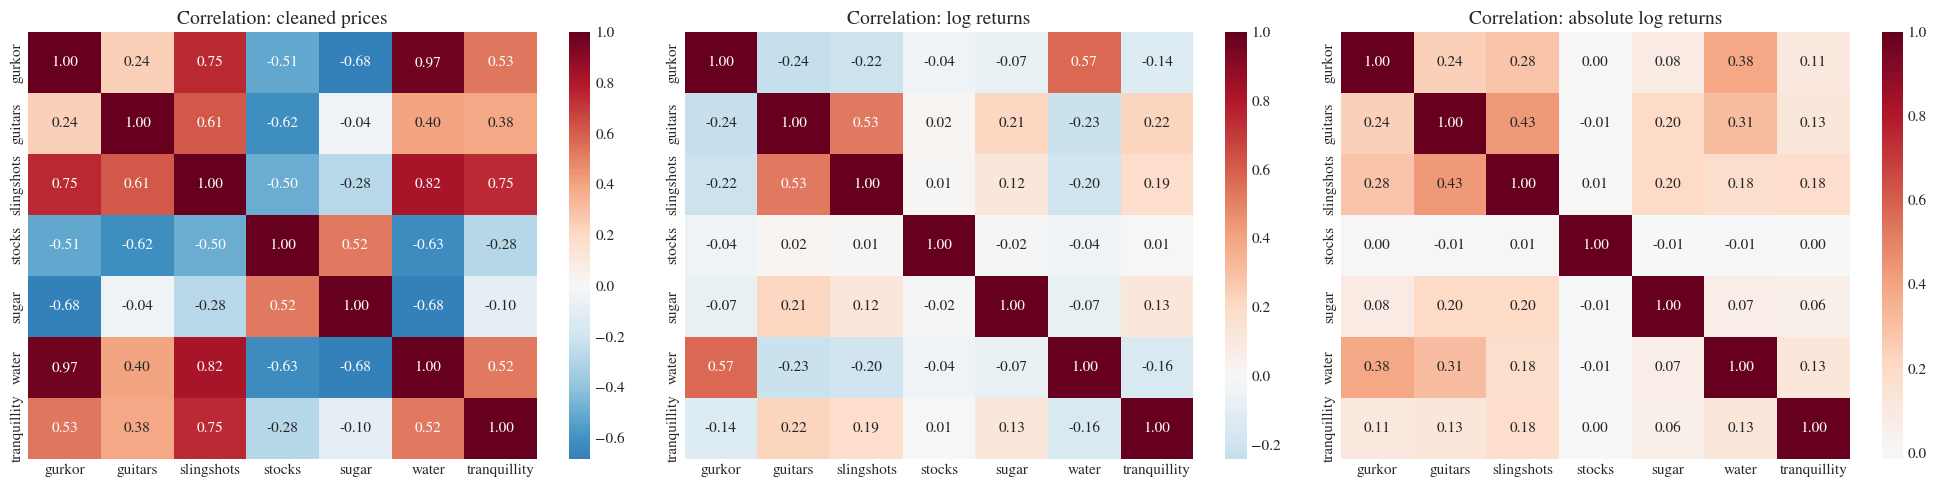

,asset_1,asset_2,log_return_correlation
least_correlated_pair,gurkor,guitars,-0.241075
most_correlated_pair,gurkor,water,0.573293



Relationship interpretation:
- Weakest return relationship: gurkor vs guitars (corr=-0.241)
- Strongest return relationship: gurkor vs water (corr=0.573)
- Price correlations are typically higher than return correlations, consistent with trending/non-stationary levels.


In [29]:
corr_prices = cleaned_prices.corr()
corr_returns = log_returns.corr()
corr_abs_returns = abs_log_returns.corr()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.heatmap(corr_prices, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Correlation: cleaned prices")

sns.heatmap(corr_returns, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Correlation: log returns")

sns.heatmap(corr_abs_returns, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[2])
axes[2].set_title("Correlation: absolute log returns")

plt.tight_layout()
plt.savefig(output / "relationship_heatmaps_task1.png")
plt.show()

pair_summary = analysis.log_return_pair_summary()
display(pair_summary)
pair_summary.to_latex(output / "ReturnPairSummary.tex")

weak_row = pair_summary.loc["least_correlated_pair"]
strong_row = pair_summary.loc["most_correlated_pair"]

print("\nRelationship interpretation:")
print(
    f"- Weakest return relationship: {weak_row['asset_1']} vs {weak_row['asset_2']} "
    f"(corr={weak_row['log_return_correlation']:.3f})"
)
print(
    f"- Strongest return relationship: {strong_row['asset_1']} vs {strong_row['asset_2']} "
    f"(corr={strong_row['log_return_correlation']:.3f})"
)
print("- Price correlations are typically higher than return correlations, consistent with trending/non-stationary levels.")

## 4) Can the series be grouped?

We infer groups from log-return correlations using both threshold grouping and hierarchical clustering.

,group,group_members,group_size,avg_within_group_correlation
asset,,,,
guitars,1,"guitars, slingshots",2,0.526253
slingshots,1,"guitars, slingshots",2,0.526253
gurkor,2,"gurkor, water",2,0.573293
water,2,"gurkor, water",2,0.573293
stocks,3,stocks,1,NaN
sugar,4,sugar,1,NaN
tranquillity,5,tranquillity,1,NaN


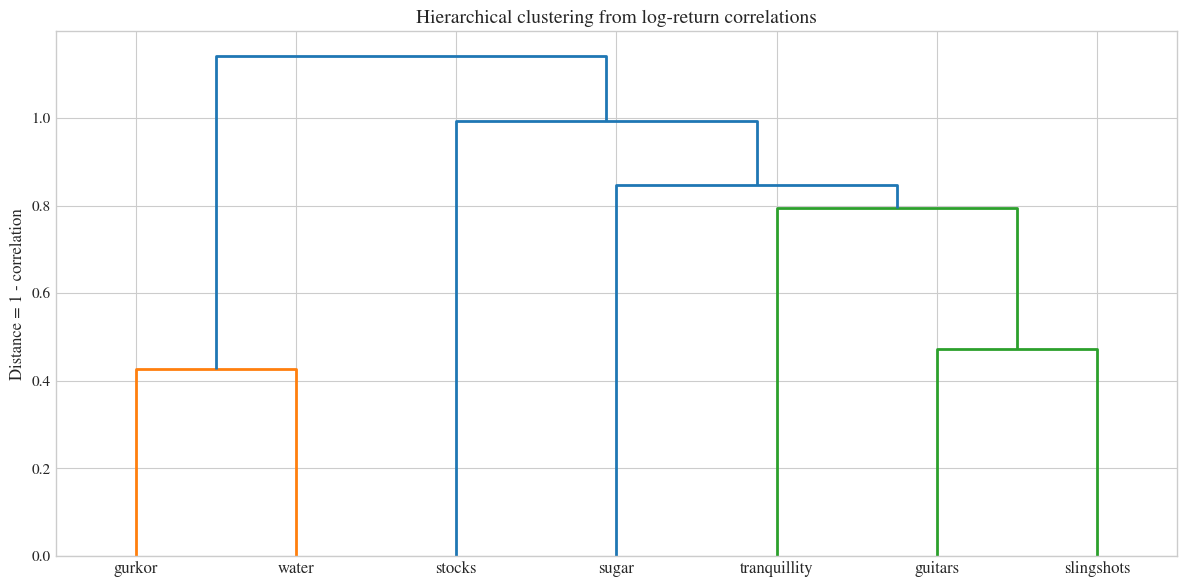

,series,cluster
0,gurkor,1
5,water,1
1,guitars,2
2,slingshots,2
6,tranquillity,3
4,sugar,4
3,stocks,5



Task 1 concise conclusions:
1) Individual patterns: strong autocorrelation in levels, weaker autocorrelation in returns, and volatility clustering in several series.
2) Relationships: multiple positive co-movements exist, with clear strongest and weakest return pairs.
3) Grouping: both threshold and hierarchical methods indicate coherent groups rather than fully independent series.


In [30]:
# Threshold-based groups from return correlation
group_table = analysis.correlation_groups(log_returns, threshold=0.30)
display(group_table)
group_table.to_latex(output / "CorrelationGroups.tex")

# Hierarchical clustering on return-correlation distance
corr_returns = log_returns.corr().fillna(0.0)
distance = (1 - corr_returns).copy()
distance_values = distance.to_numpy(copy=True)
np.fill_diagonal(distance_values, 0.0)
link = linkage(squareform(distance_values, checks=False), method="average")

plt.figure(figsize=(12, 6))
dendrogram(link, labels=corr_returns.columns.tolist())
plt.title("Hierarchical clustering from log-return correlations")
plt.ylabel("Distance = 1 - correlation")
plt.tight_layout()
plt.savefig(output / "return_correlation_dendrogram_task1.png")
plt.show()

cluster_labels = fcluster(link, t=0.75, criterion="distance")
cluster_df = pd.DataFrame({"series": corr_returns.columns, "cluster": cluster_labels}).sort_values(["cluster", "series"])
display(cluster_df)
cluster_df.to_latex(output / "HierarchicalClusters.tex", index=False)

print("\nTask 1 concise conclusions:")
print("1) Individual patterns: strong autocorrelation in levels, weaker autocorrelation in returns, and volatility clustering in several series.")
print("2) Relationships: multiple positive co-movements exist, with clear strongest and weakest return pairs.")
print("3) Grouping: both threshold and hierarchical methods indicate coherent groups rather than fully independent series.")